<a href="https://colab.research.google.com/github/62Laura/vaccine-sentiment-nlp/blob/main/notebooks/03e_model5_distilbert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing required packages

In [1]:
!pip install -q transformers datasets scikit-learn pandas matplotlib seaborn

import torch

if torch.cuda.is_available():
    print("GPU is available:", torch.cuda.get_device_name(0))
else:
    print("No GPU found. Go to Runtime > Change runtime type > select GPU (T4)")

GPU is available: Tesla T4


Load Data and build the training set

In [3]:
import pandas as pd

RAW_URL = "https://raw.githubusercontent.com/62Laura/vaccine-sentiment-nlp/main/data/raw/Train.csv"
VAL_URL = "https://raw.githubusercontent.com/62Laura/vaccine-sentiment-nlp/main/data/processed/val.csv"
TEST_URL = "https://raw.githubusercontent.com/62Laura/vaccine-sentiment-nlp/main/data/processed/test.csv"

train_full = pd.read_csv(RAW_URL)
val_df = pd.read_csv(VAL_URL)
test_df = pd.read_csv(TEST_URL)

print("rows before dropping missing labels:", len(train_full))
train_full = train_full.dropna(subset=["label"]).reset_index(drop=True)
print("rows after dropping missing labels:", len(train_full))

train_full["label"] = train_full["label"].astype(int) + 1

used_ids = set(val_df["tweet_id"]).union(set(test_df["tweet_id"]))
train_df = train_full[~train_full["tweet_id"].isin(used_ids)].reset_index(drop=True)

train_df = train_df.rename(columns={"safe_text": "text_clean"})

print("train rows:", len(train_df))
print("val rows:", len(val_df))
print("test rows:", len(test_df))
print(train_df["label"].value_counts())

rows before dropping missing labels: 10001
rows after dropping missing labels: 10000
train rows: 7000
val rows: 1500
test rows: 1500
label
1    3436
2    2837
0     727
Name: count, dtype: int64


Tokenize text and build dataset objects

In [4]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text_clean"], truncation=True, padding="max_length", max_length=64)

train_ds = Dataset.from_pandas(train_df[["text_clean", "label"]])
val_ds = Dataset.from_pandas(val_df[["text_clean", "label"]])
test_ds = Dataset.from_pandas(test_df[["text_clean", "label"]])

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds = train_ds.rename_column("label", "labels")
val_ds = val_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels")

columns = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=columns)
val_ds.set_format(type="torch", columns=columns)
test_ds.set_format(type="torch", columns=columns)

print(train_ds[0])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

{'labels': tensor(1), 'input_ids': tensor([  101,  2033,  1004, 23713,  1025,  1996,  2502,  7570,  9856,  2812,
        11097, 14142,  8889,  1001,  2812, 11097,  1001, 16914,  1001, 16914,
         2015,  1001,  3461,  2099,  1001, 26261, 25494, 15509,  1030, 26261,
        25494,  2358,  1012,  1026, 24471,  2140,  1028,   102,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}


Load model and set up training

In [5]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1, "precision_macro": precision, "recall_macro": recall}

training_args = TrainingArguments(
    output_dir="./distilbert_vaccine",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train the model

In [6]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,No log,0.587728,0.761333,0.543163,0.846544,0.572300
2,0.690301,0.570911,0.769333,0.652165,0.735251,0.632502
3,0.509763,0.561253,0.763333,0.669501,0.681722,0.661245


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1314, training_loss=0.5607378885626249, metrics={'train_runtime': 146.6837, 'train_samples_per_second': 143.165, 'train_steps_per_second': 8.958, 'total_flos': 347733122688000.0, 'train_loss': 0.5607378885626249, 'epoch': 3.0})

Evaluate on test set

In [7]:
test_results = trainer.evaluate(test_ds)
print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision Macro,Recall Macro
0.509763,0.631438,3,0.754667,0.668617,0.678644,0.661321


{'eval_loss': 0.6314377188682556, 'eval_accuracy': 0.7546666666666667, 'eval_f1_macro': 0.6686173106839973, 'eval_precision_macro': 0.6786437843371185, 'eval_recall_macro': 0.6613211191300437}


Confusion Matrix

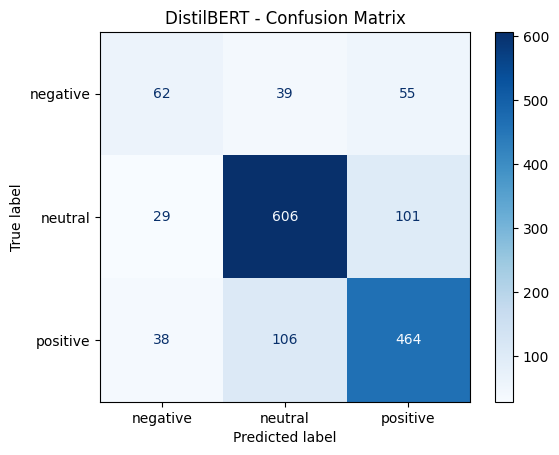

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("DistilBERT - Confusion Matrix")
plt.savefig("model5_distilbert.png", bbox_inches="tight")
plt.show()

Build results

In [9]:
row = {
    "model_name": "model5_distilbert",
    "accuracy": test_results["eval_accuracy"],
    "macro_f1": test_results["eval_f1_macro"],
    "precision_macro": test_results["eval_precision_macro"],
    "recall_macro": test_results["eval_recall_macro"],
    "train_time_s": 146.68,
    "notes": "distilbert-base-uncased, max_len=64, batch=16, lr=2e-5, 3 epochs, best model on val f1_macro"
}

print(",".join(str(v) for v in row.values()))

model5_distilbert,0.7546666666666667,0.6686173106839973,0.6786437843371185,0.6613211191300437,146.68,distilbert-base-uncased, max_len=64, batch=16, lr=2e-5, 3 epochs, best model on val f1_macro


Compare all 5 models

                 model_name  accuracy  macro_f1  precision_macro  recall_macro
0  TFIDF_LogisticRegression  0.727333  0.664007         0.653890      0.692163
1          tfidf_linear_svm  0.717000  0.634000         0.633000      0.635000
2             model3_bilstm  0.712000  0.638000         0.632000      0.647000
3            model4_textcnn  0.671000  0.603000         0.596000      0.625000
4         model5_distilbert  0.754667  0.668617         0.678644      0.661321


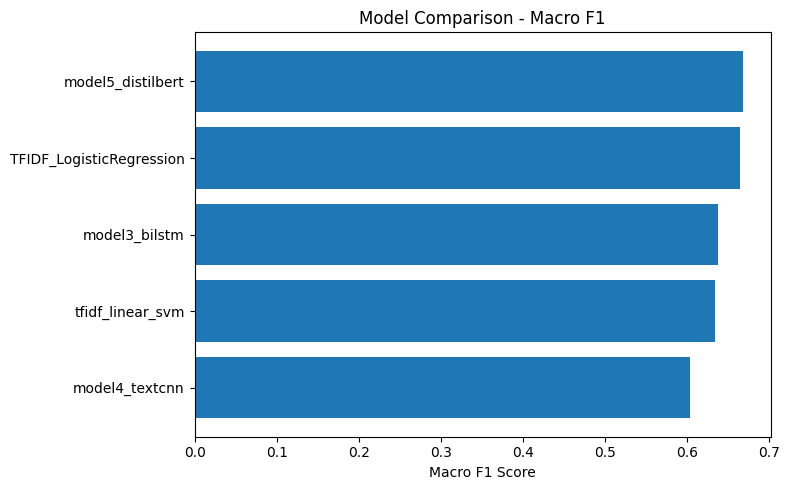

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

summary_url = "https://raw.githubusercontent.com/62Laura/vaccine-sentiment-nlp/main/results/metrics_summary.csv"
summary = pd.read_csv(summary_url)

print(summary[["model_name", "accuracy", "macro_f1", "precision_macro", "recall_macro"]])

summary_sorted = summary.sort_values("macro_f1", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(summary_sorted["model_name"], summary_sorted["macro_f1"])
plt.xlabel("Macro F1 Score")
plt.title("Model Comparison - Macro F1")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("model_comparison_f1.png")
plt.show()